In [1]:
!nvidia-smi || echo "GPU не найден. В среды Colab включите Runtime -> Change runtime type -> Hardware accelerator: GPU"

Tue Apr 21 21:03:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1060 6GB  WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   28C    P8             10W /  156W |     727MiB /   6144MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

2.7.1+cu118
CUDA available: True
CUDA device count: 1
GPU: NVIDIA GeForce GTX 1060 6GB


In [1]:
from pathlib import Path
import random
import shutil
import yaml
import os

PROJECT_ROOT = Path.cwd().resolve().parents[1]

ML_DIR = PROJECT_ROOT / "ml_training"
DATA_DIR = ML_DIR / "data"
DATASET_DIR = DATA_DIR / "dataset_nutrition"

RAW_DIR = DATASET_DIR / "raw"
RAW_IMAGES = RAW_DIR / "images"
RAW_LABELS = RAW_DIR / "labels"

TRAIN_DIR = DATASET_DIR / "train"
VALID_DIR = DATASET_DIR / "valid"
TEST_DIR = DATASET_DIR / "test"

CONFIG_DIR = ML_DIR / "configs"
DATA_YAML_PATH = CONFIG_DIR / "data.yaml"

RUNS_DIR = PROJECT_ROOT / "runs"
NUTRITION_JSON_PATH = PROJECT_ROOT/ "ml_api" / "data" / "nutrition_products_ru_kbju_100g.json"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_IMAGES:", RAW_IMAGES)
print("RAW_LABELS:", RAW_LABELS)
print("TRAIN_DIR:", TRAIN_DIR)
print("VALID_DIR:", VALID_DIR)
print("TEST_DIR:", TEST_DIR)
print("DATA_YAML_PATH:", DATA_YAML_PATH)
print("NUTRITION_JSON_PATH:", NUTRITION_JSON_PATH)

print("\nПроверка структуры:")
print("RAW_IMAGES exists:", RAW_IMAGES.exists())
print("RAW_LABELS exists:", RAW_LABELS.exists())
print("DATA_YAML exists:", DATA_YAML_PATH.exists())
print("JSON exists:", NUTRITION_JSON_PATH.exists())

PROJECT_ROOT: E:\NutritionProject
RAW_IMAGES: E:\NutritionProject\ml_training\data\dataset_nutrition\raw\images
RAW_LABELS: E:\NutritionProject\ml_training\data\dataset_nutrition\raw\labels
TRAIN_DIR: E:\NutritionProject\ml_training\data\dataset_nutrition\train
VALID_DIR: E:\NutritionProject\ml_training\data\dataset_nutrition\valid
TEST_DIR: E:\NutritionProject\ml_training\data\dataset_nutrition\test
DATA_YAML_PATH: E:\NutritionProject\ml_training\configs\data.yaml
NUTRITION_JSON_PATH: E:\NutritionProject\ml_api\data\nutrition_products_ru_kbju_100g.json

Проверка структуры:
RAW_IMAGES exists: True
RAW_LABELS exists: True
DATA_YAML exists: True
JSON exists: True


In [5]:
IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".webp"]

image_files = []
for ext in IMAGE_EXTS:
    image_files.extend(RAW_IMAGES.glob(f"*{ext}"))

print("Найдено исходных изображений:", len(image_files))
print("Найдено label-файлов:", len(list(RAW_LABELS.glob("*.txt"))))

Найдено исходных изображений: 1280
Найдено label-файлов: 1280


In [6]:
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

random.seed(42)

for split_dir in [TRAIN_DIR, VALID_DIR, TEST_DIR]:
    if split_dir.exists():
        shutil.rmtree(split_dir)

for split_dir in [TRAIN_DIR, VALID_DIR, TEST_DIR]:
    (split_dir / "images").mkdir(parents=True, exist_ok=True)
    (split_dir / "labels").mkdir(parents=True, exist_ok=True)

image_files = []
for ext in IMAGE_EXTS:
    image_files.extend(RAW_IMAGES.glob(f"*{ext}"))

image_files = sorted(image_files)
random.shuffle(image_files)

total = len(image_files)
train_count = int(total * TRAIN_RATIO)
val_count = int(total * VAL_RATIO)
test_count = total - train_count - val_count

train_files = image_files[:train_count]
val_files = image_files[train_count:train_count + val_count]
test_files = image_files[train_count + val_count:]

def copy_split(files, split_dir):
    missing_labels = []
    for img_path in files:
        label_path = RAW_LABELS / f"{img_path.stem}.txt"

        shutil.copy2(img_path, split_dir / "images" / img_path.name)

        if label_path.exists():
            shutil.copy2(label_path, split_dir / "labels" / label_path.name)
        else:
            missing_labels.append(img_path.name)

    return missing_labels

missing_train = copy_split(train_files, TRAIN_DIR)
missing_val = copy_split(val_files, VALID_DIR)
missing_test = copy_split(test_files, TEST_DIR)

In [7]:
for split_name, split_dir in [("train", TRAIN_DIR), ("valid", VALID_DIR), ("test", TEST_DIR)]:
    img_count = len(list((split_dir / "images").glob("*")))
    lbl_count = len(list((split_dir / "labels").glob("*.txt")))
    print(f"{split_name}: images={img_count}, labels={lbl_count}")

train: images=1024, labels=1024
valid: images=128, labels=128
test: images=128, labels=128


In [4]:
if DATA_YAML_PATH.exists():
    with open(DATA_YAML_PATH, "r", encoding="utf-8") as f:
        data_yaml = yaml.safe_load(f)

    print("Содержимое data.yaml:")
    print(data_yaml)
else:
    print("Файл data.yaml не найден:", DATA_YAML_PATH)

Содержимое data.yaml:
{'train': '/NutritionProject/ml/data/dataset_nutrition/train/images', 'val': '/NutritionProject/ml/data/dataset_nutrition/valid/images', 'test': 'NutritionProject/ml/data/dataset_nutrition/test/images', 'nc': 53, 'names': ['apple', 'avocado', 'bacon', 'bagel', 'banana', 'beef', 'bell pepper', 'blueberry', 'bread', 'broccoli', 'burger', 'cabbage', 'carrot', 'champignons', 'cheese', 'chicken', 'corn', 'cucumber', 'cutlet', 'dill', 'egg', 'french fries', 'garlic', 'grape', 'green beans', 'green peas', 'hot dog', 'kiwi', 'lemon', 'lettuce', 'lime', 'mashed potato', 'noodles', 'oatmeal', 'omelette', 'onion', 'orange', 'pancakes', 'parsley', 'pasta', 'pineapple', 'pizza', 'pork', 'potato', 'rice', 'salmon', 'sausages', 'shrimp', 'spinach', 'strawberry', 'toast', 'tomato', 'tuna']}


In [1]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

In [6]:
results = model.train(
    data=str(DATA_YAML_PATH),
    epochs=50,
    imgsz=640,
    batch=4,
    workers=4,
    device=0,
    patience=20,
    project=str(RUNS_DIR),
    name="nutrition_yolo11m_aug_v1",
    exist_ok=True,
    plots=True,

    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,

    degrees=5.0,
    translate=0.08,
    scale=0.25,
    shear=0.0,
    perspective=0.0,

    fliplr=0.5,
    flipud=0.0,

    mosaic=0.5,
    mixup=0.05,
    copy_paste=0.0
)

Ultralytics 8.4.41  Python-3.13.0 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1060 6GB, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\NutritionProject\ml\configs\data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=nutrition_yolo11m_aug_v1, nbs=64, nms=False, opset=None, optimize=False, optimiz

KeyboardInterrupt: 

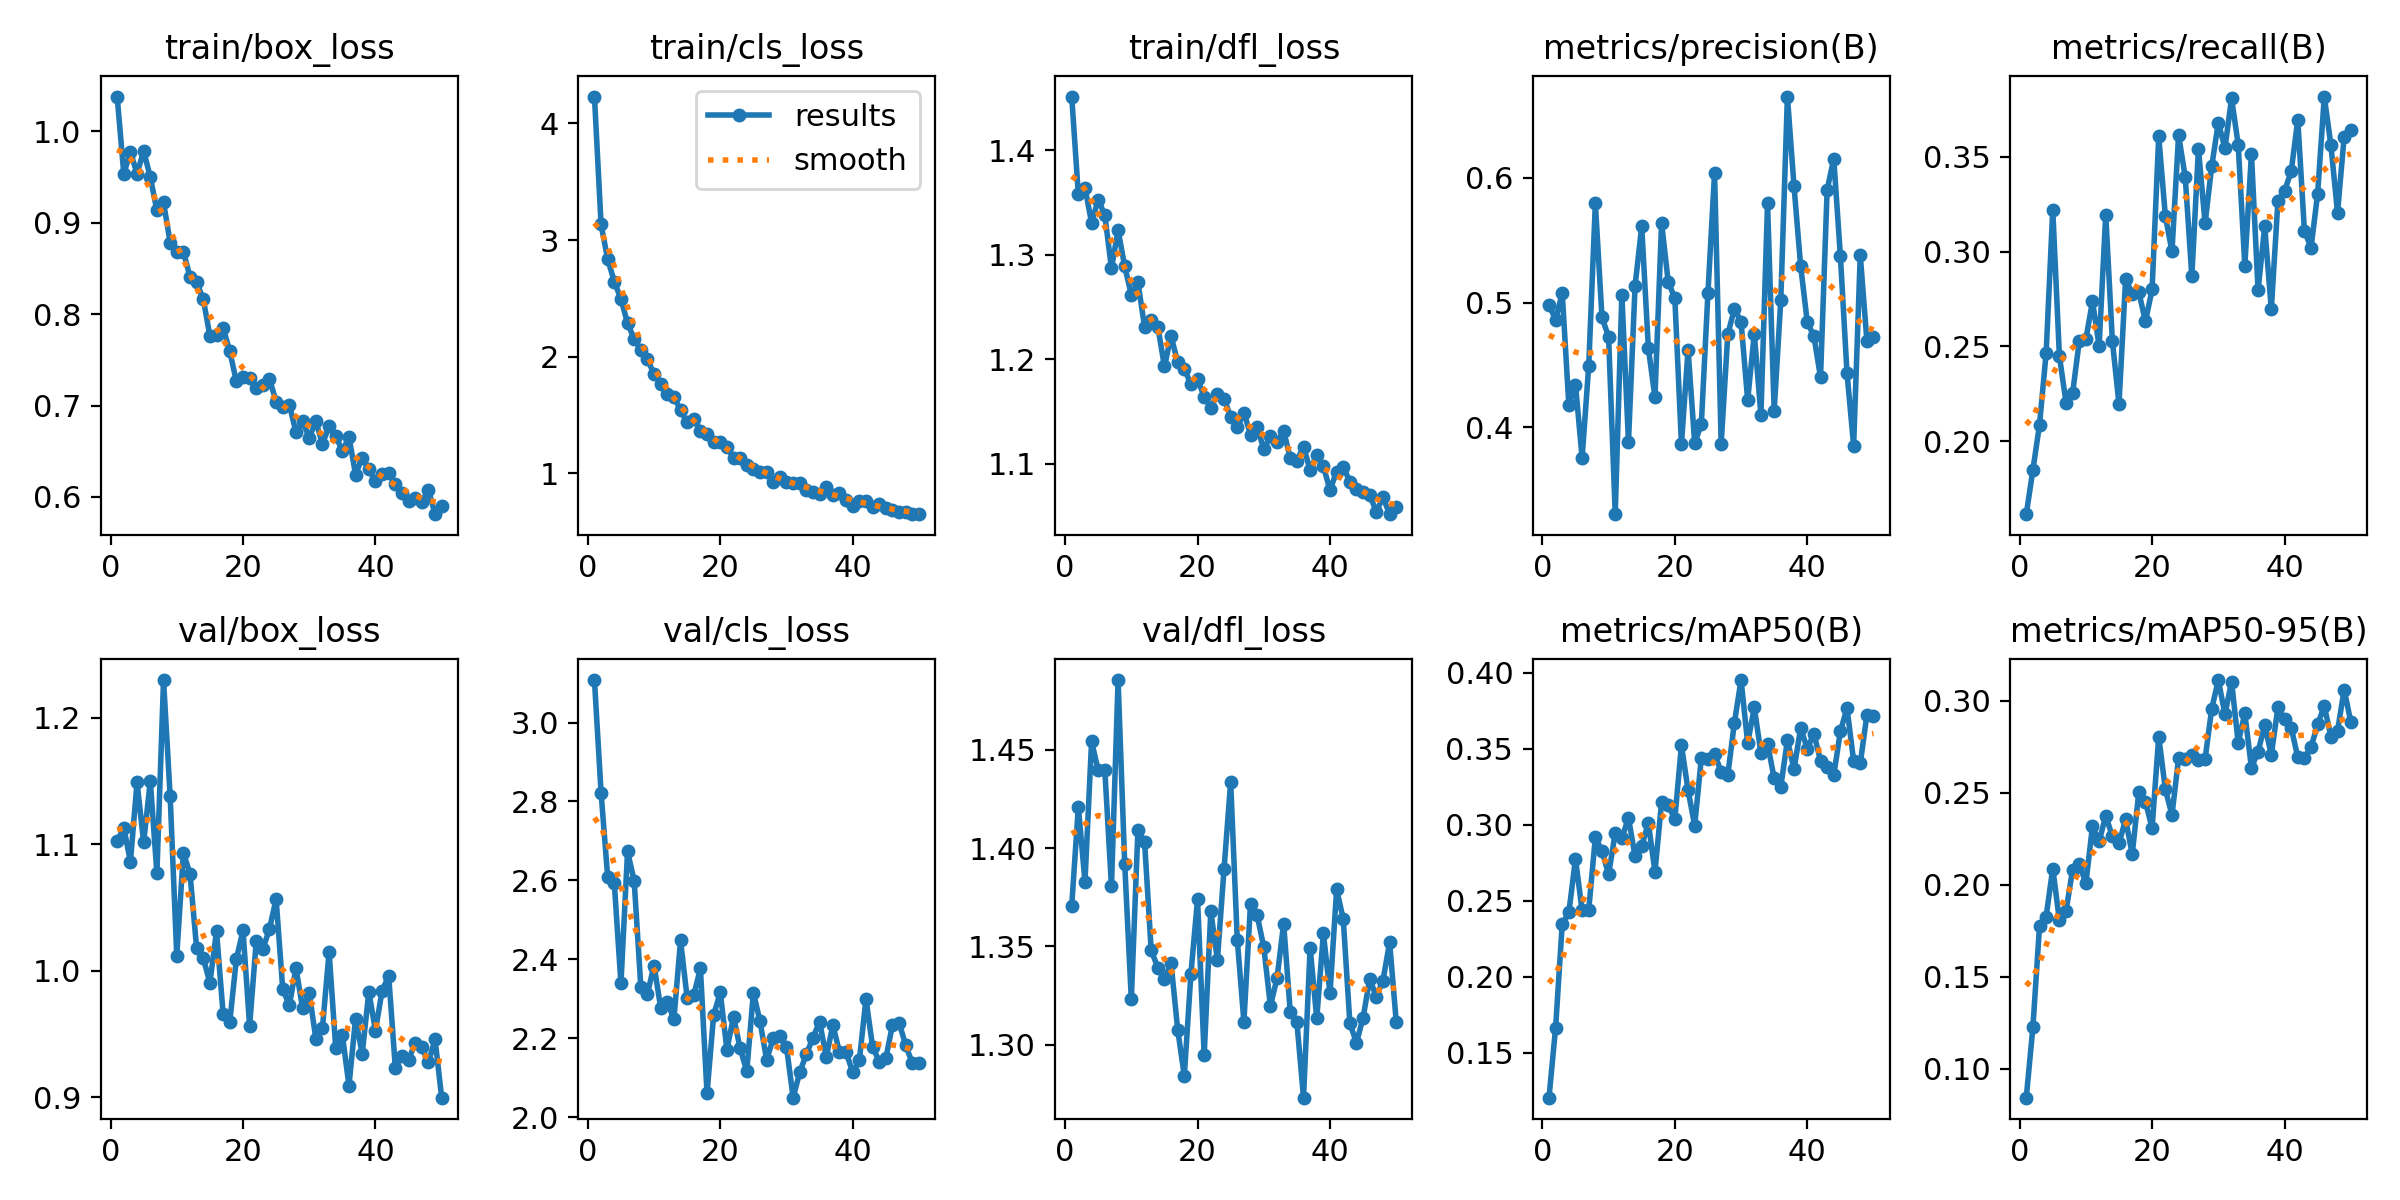

In [7]:
from IPython.display import Image, display

display(Image(str(RUNS_DIR / "nutrition_yolo11m_aug_v1" / "results.png")))

Ultralytics 8.4.41  Python-3.13.0 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1060 6GB, 6144MiB)
YOLO11m summary (fused): 126 layers, 20,070,895 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 21.411.7 MB/s, size: 213.6 KB)
val: Scanning E:\NutritionProject\ml\data\dataset_nutrition\test\labels... 128 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 159.9it/s 0.8s0.1s
val: New cache created: E:\NutritionProject\ml\data\dataset_nutrition\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.6s/it 29.2s1.0s6
                   all        128        345      0.626      0.614      0.672      0.573
                 apple         12         36      0.821      0.889       0.88       0.79
               avocado         15         27      0.669      0.519      0.637      0.477
                 bacon          3          7      0.207      0.143      0.139      0.129
     

,Class,Images,Instances,Box-P,Box-R,Box-F1,mAP50,mAP50-95
0,pork,1,2,0.14309,1.00000,0.25036,0.99500,0.99500
1,pizza,1,1,1.00000,0.00000,0.00000,0.99500,0.89550
2,oatmeal,2,2,0.89426,1.00000,0.94418,0.99500,0.89550
3,orange,1,1,0.36158,1.00000,0.53112,0.99500,0.89550
4,corn,1,1,0.59307,1.00000,0.74457,0.99500,0.89550
5,toast,1,1,0.38574,1.00000,0.55673,0.99500,0.89550
6,omelette,1,1,0.26900,1.00000,0.42396,0.99500,0.89550
7,pasta,1,1,0.90119,1.00000,0.94803,0.99500,0.89550
8,bell pepper,8,9,0.75292,1.00000,0.85905,0.95500,0.85613
9,strawberry,10,10,0.87342,0.90000,0.88651,0.94750,0.84825


Per-class metrics saved to: E:\NutritionProject\runs\nutrition_yolo11m_aug_v1_val\per_class_metrics.csv

=== Speed (ms/image) ===
preprocess: 46.5191
inference: 31.8447
loss: 0.0007
postprocess: 20.6903

=== Curves available ===
['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']

=== Saved plots ===
E:\NutritionProject\runs\nutrition_yolo11m_aug_v1_val\confusion_matrix.png


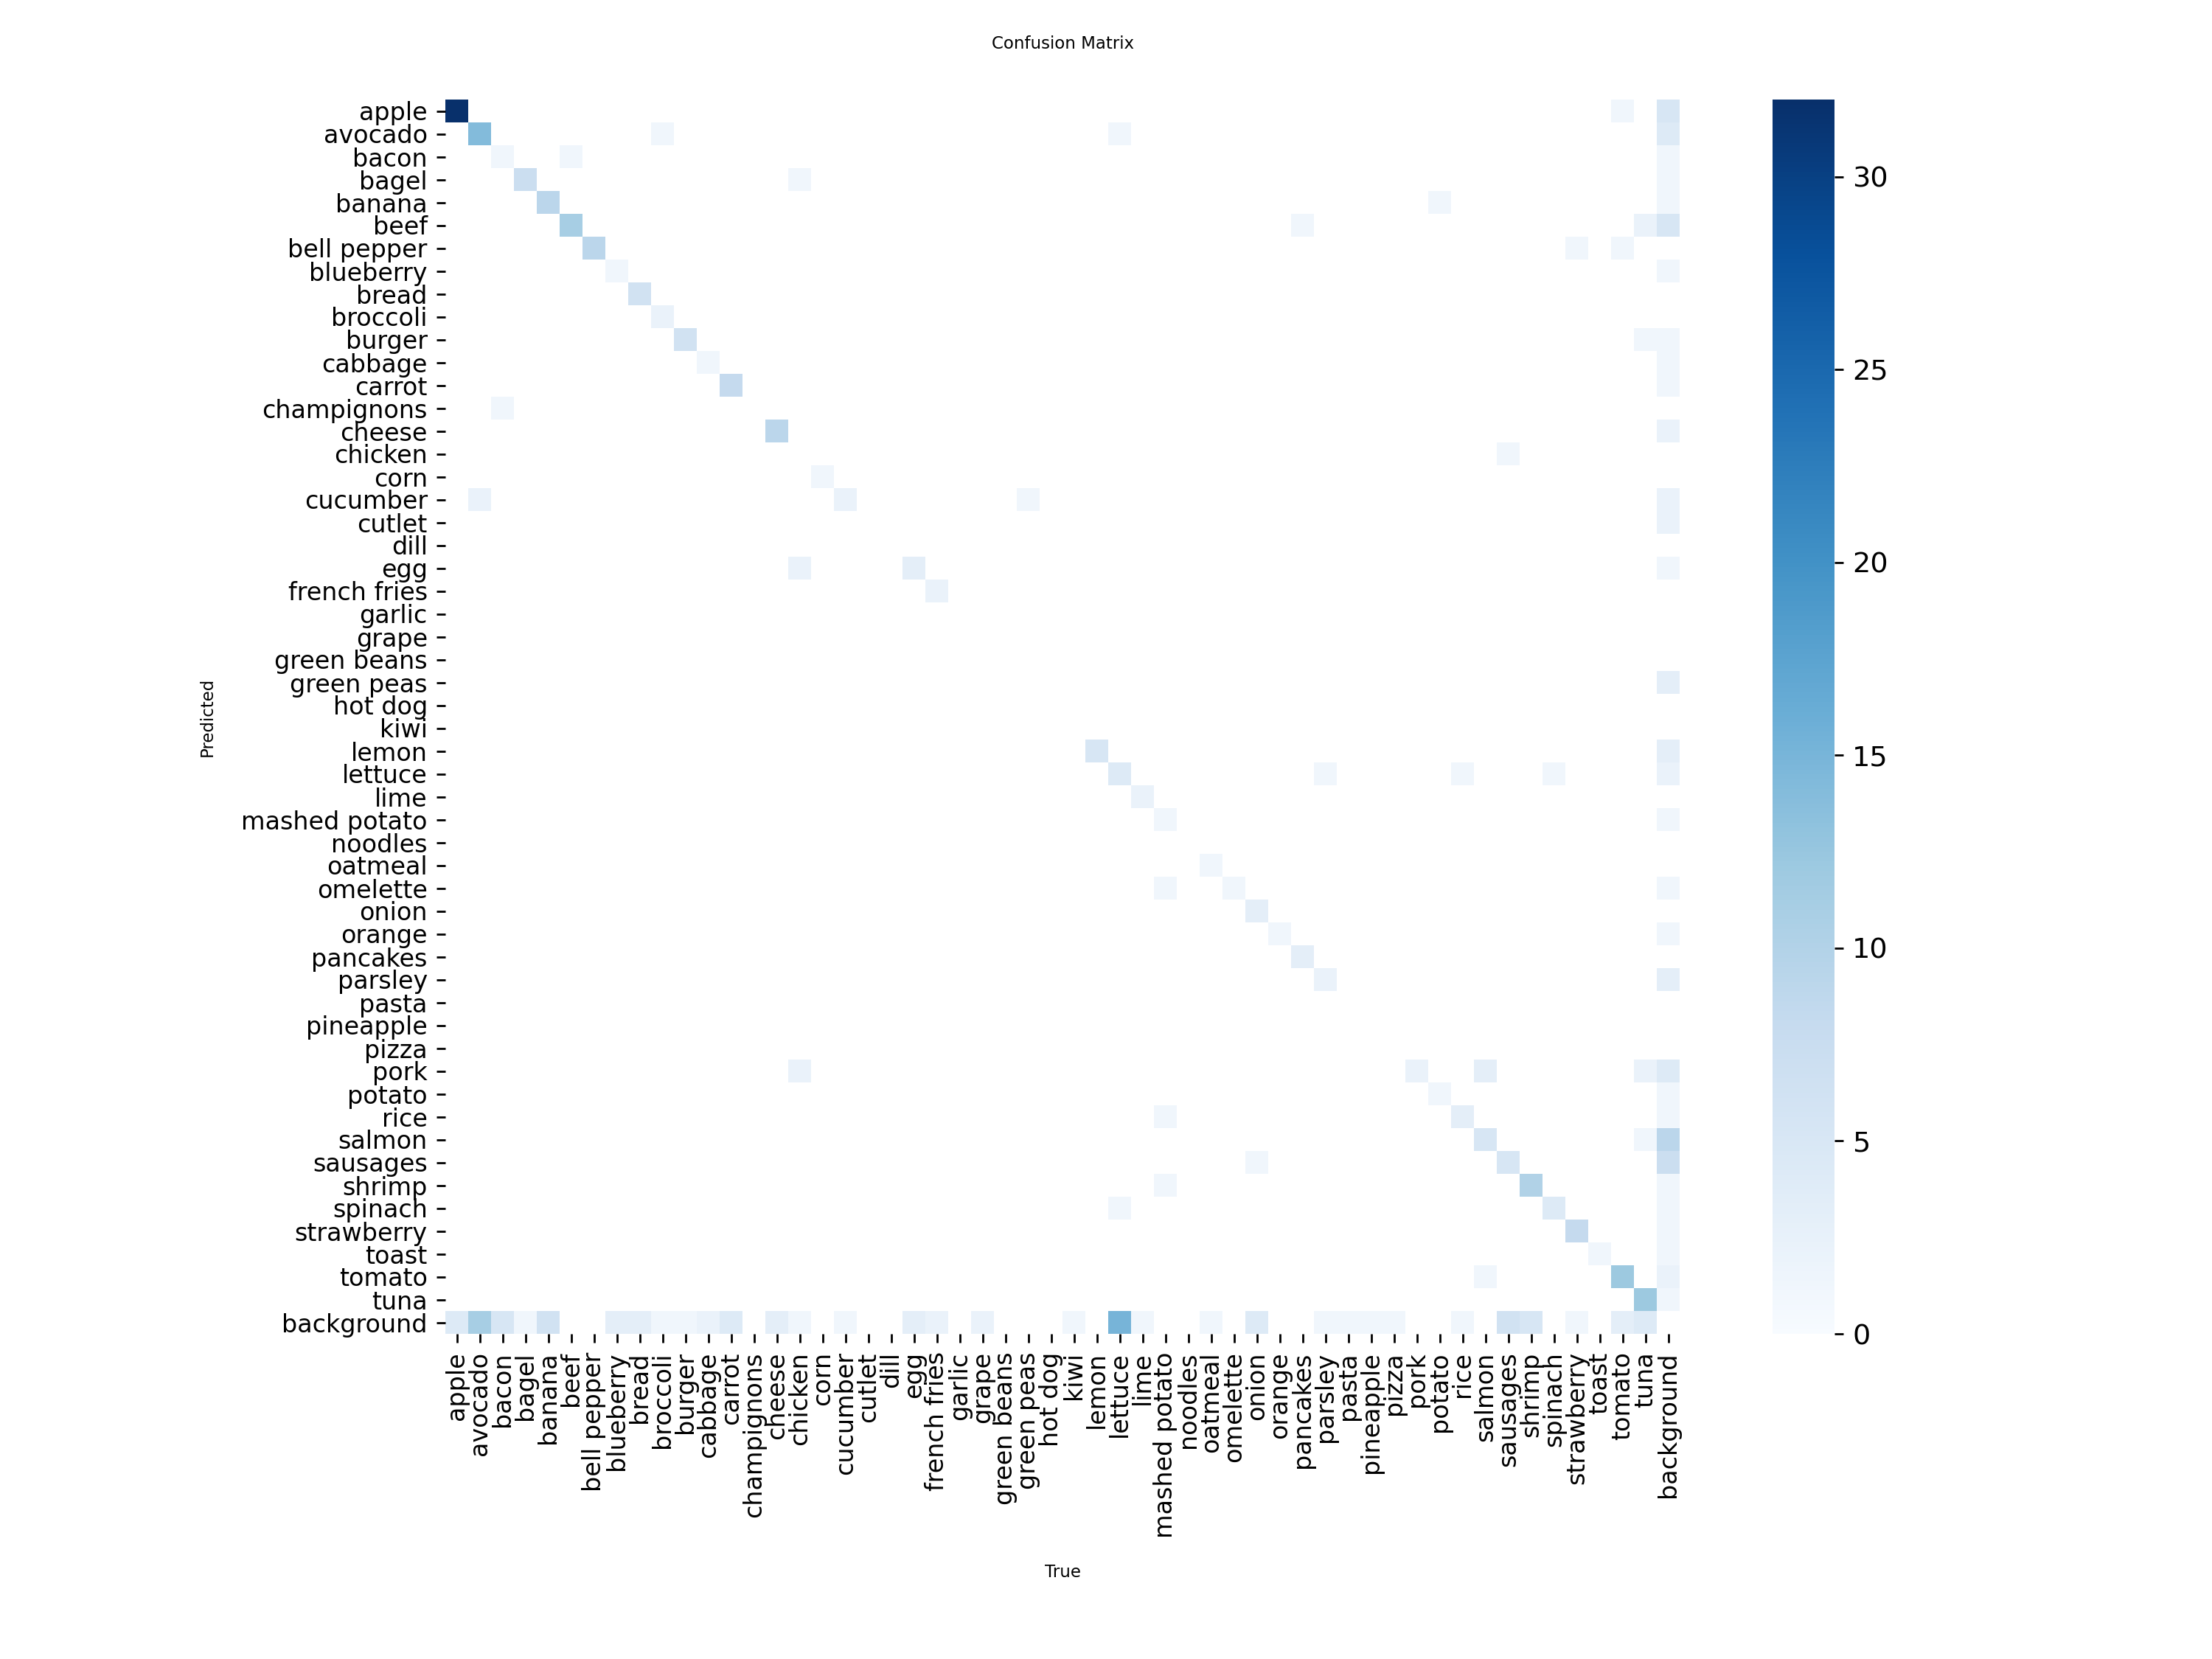

E:\NutritionProject\runs\nutrition_yolo11m_aug_v1_val\confusion_matrix_normalized.png


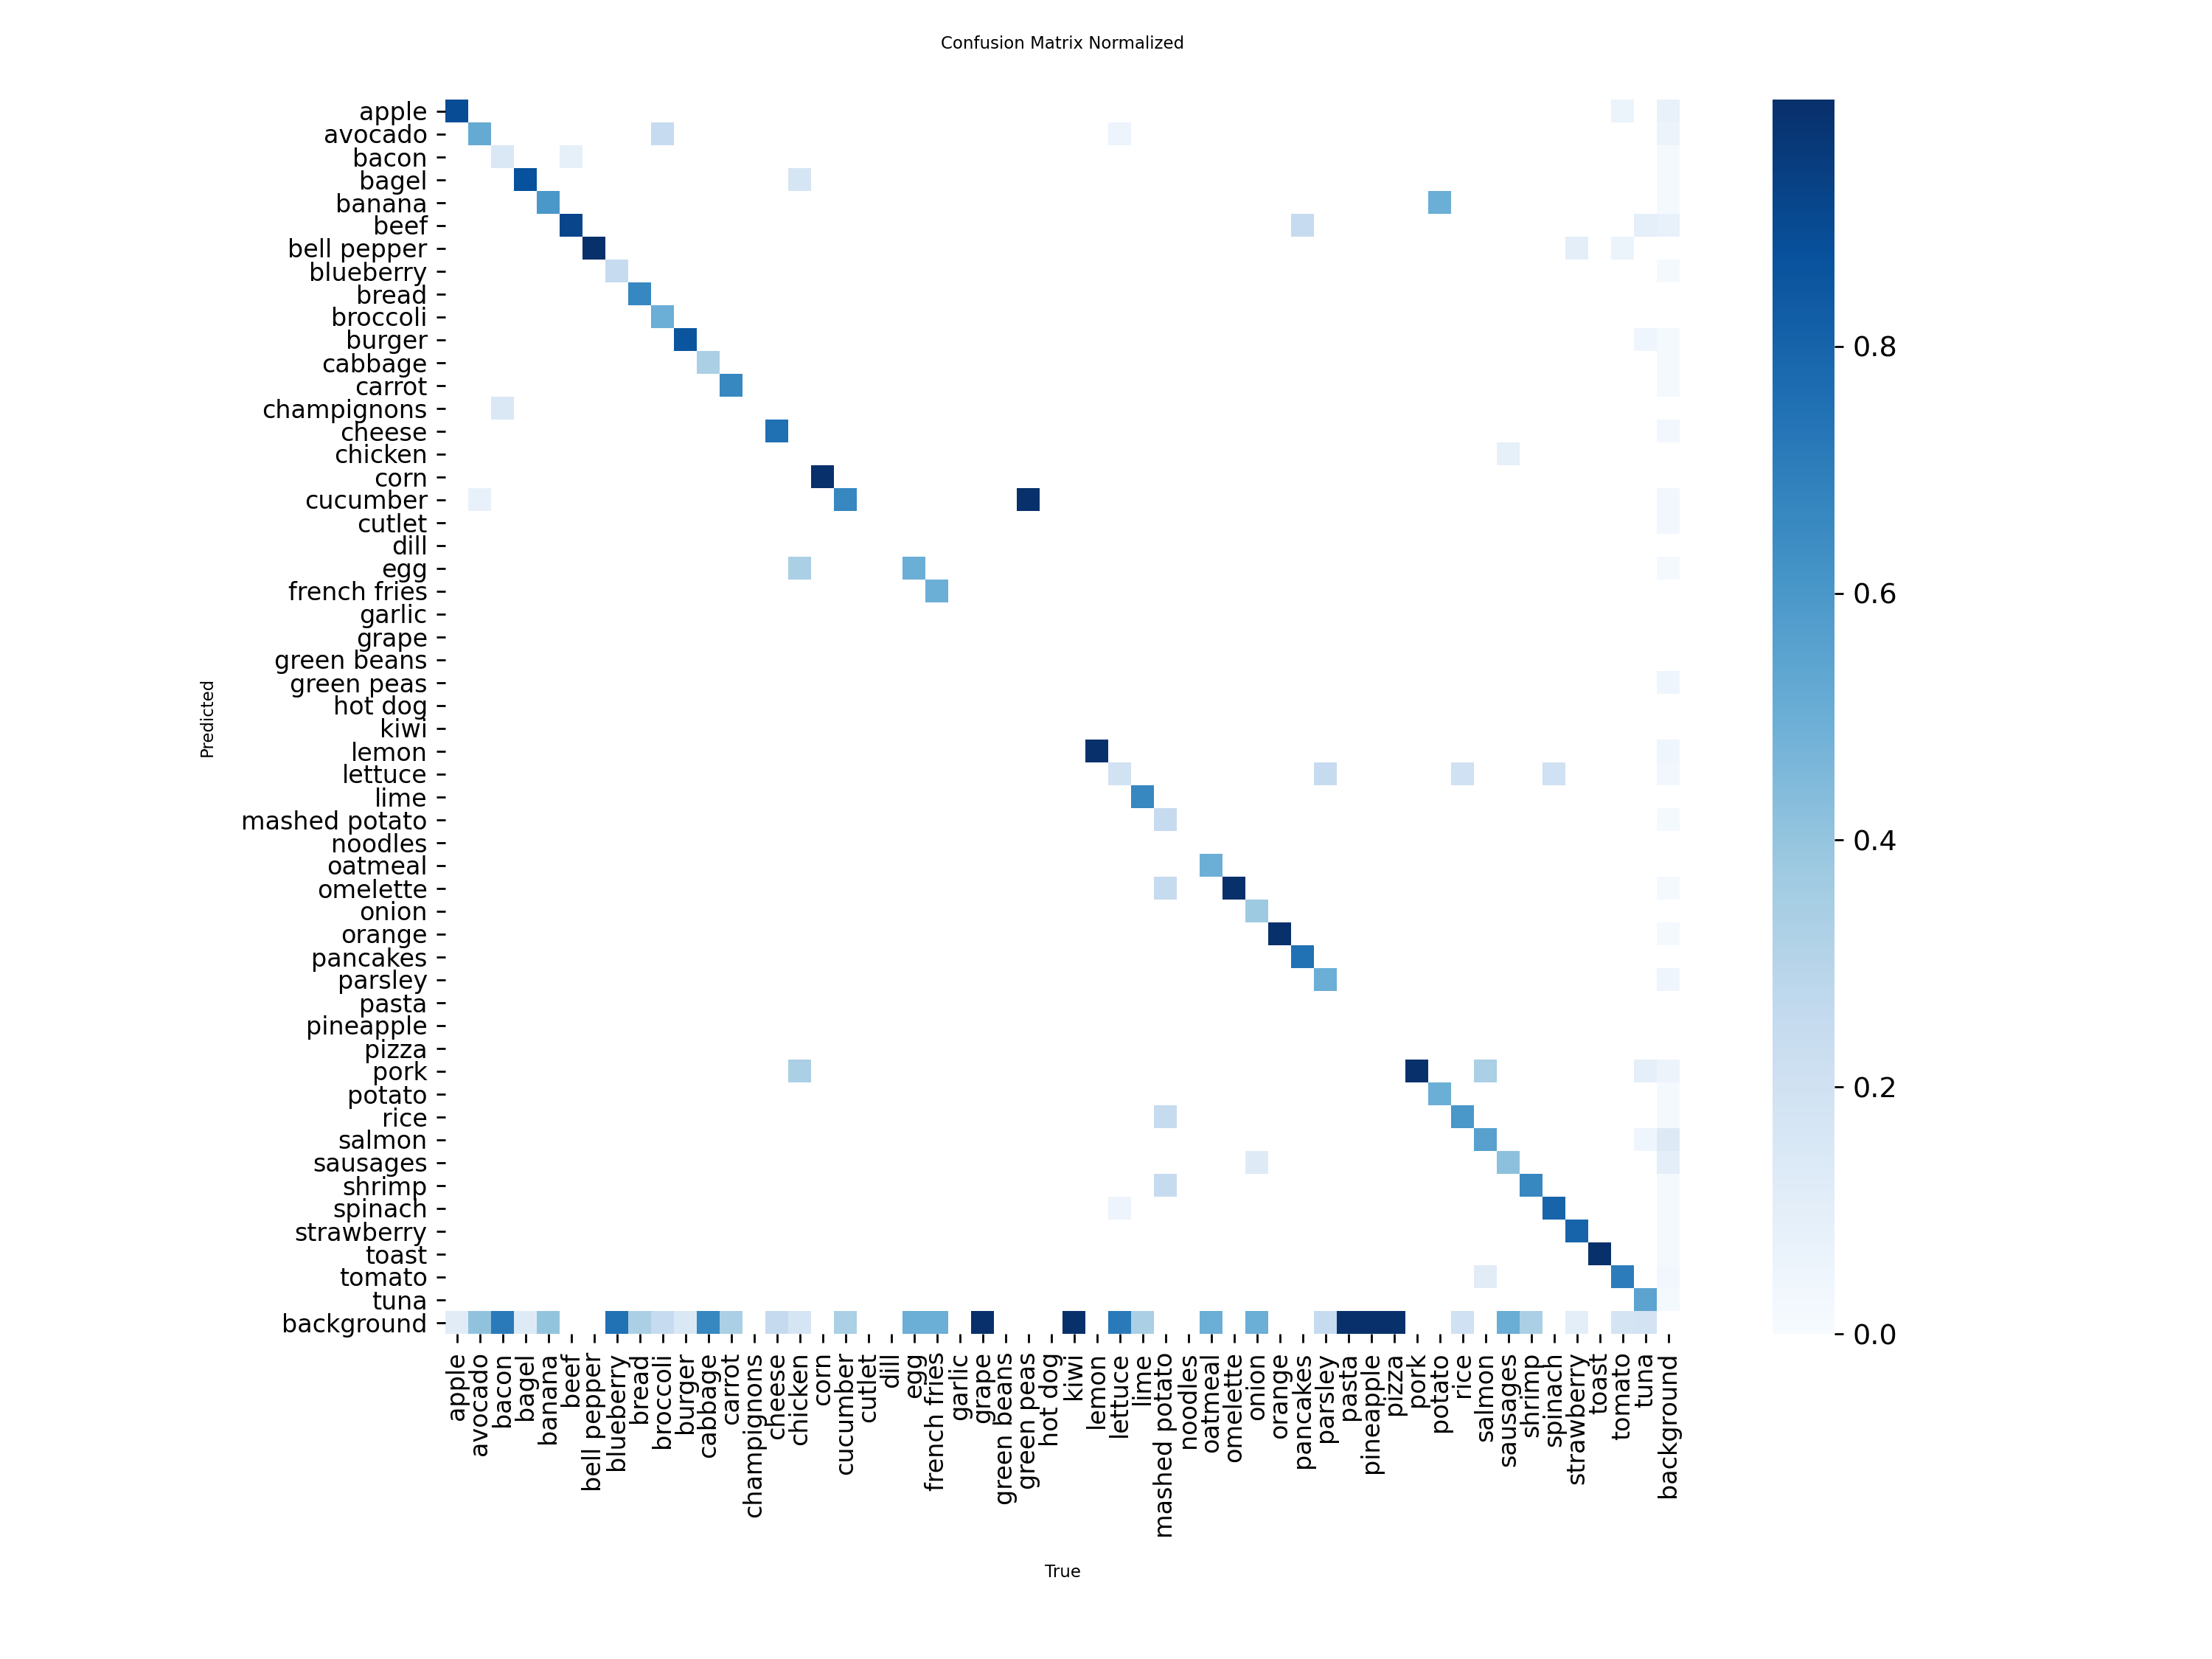

E:\NutritionProject\runs\nutrition_yolo11m_aug_v1_val\BoxPR_curve.png


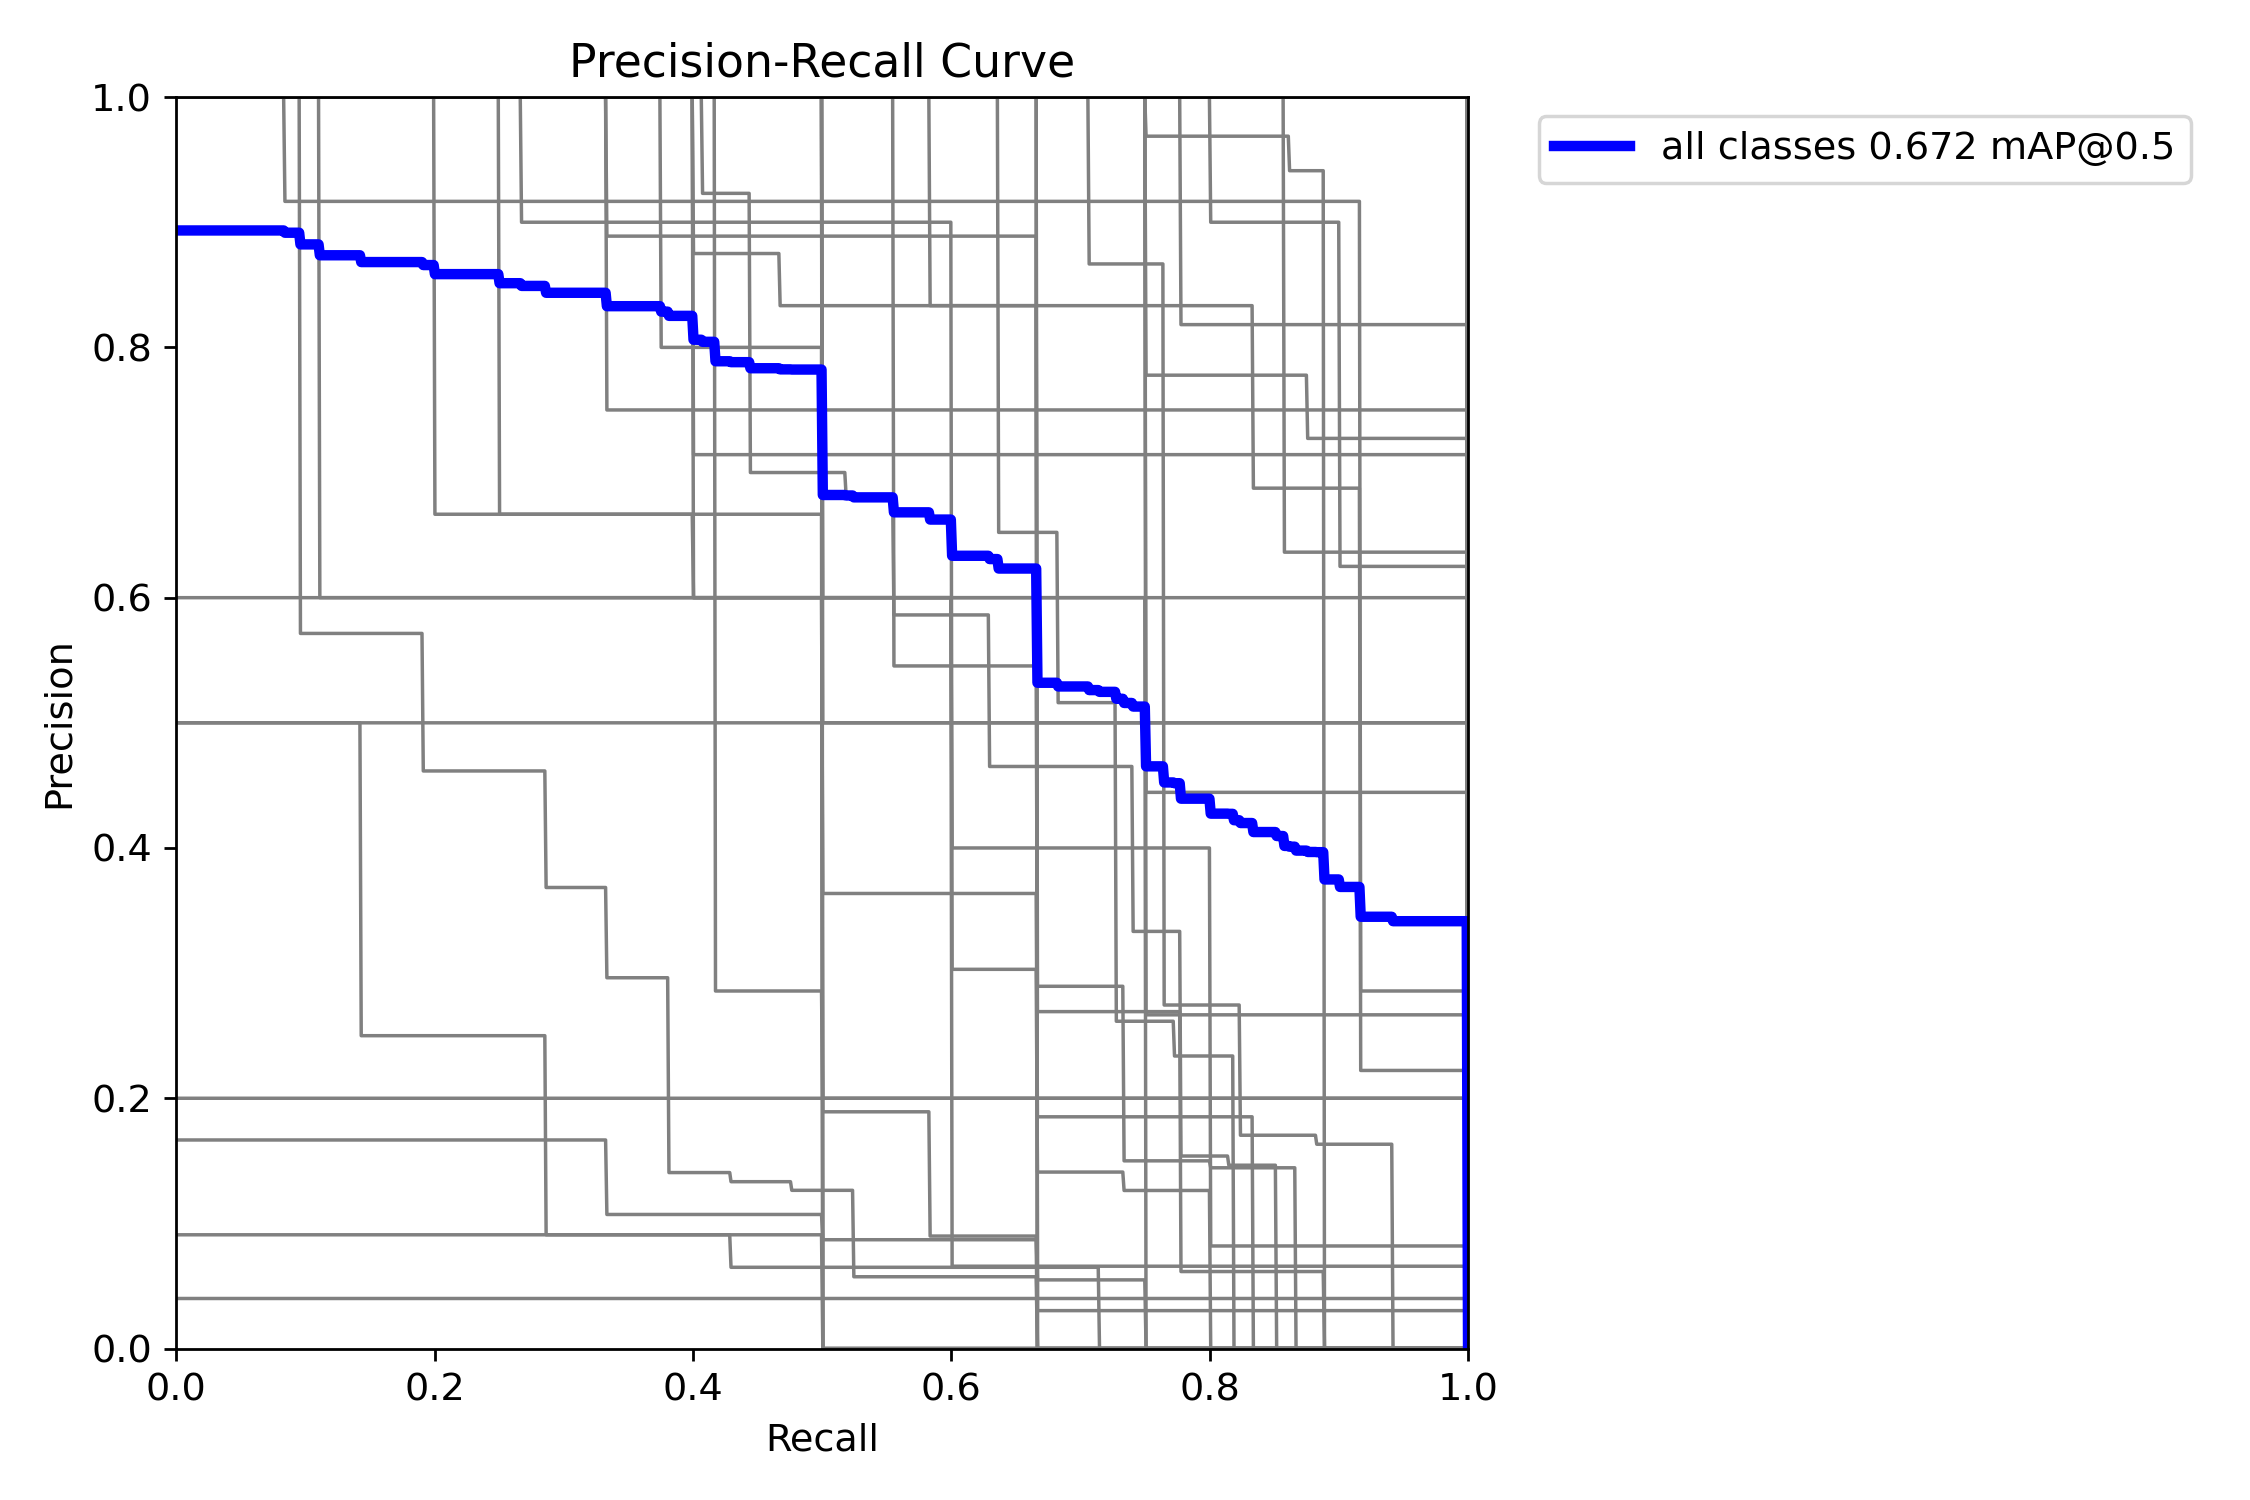

E:\NutritionProject\runs\nutrition_yolo11m_aug_v1_val\BoxF1_curve.png


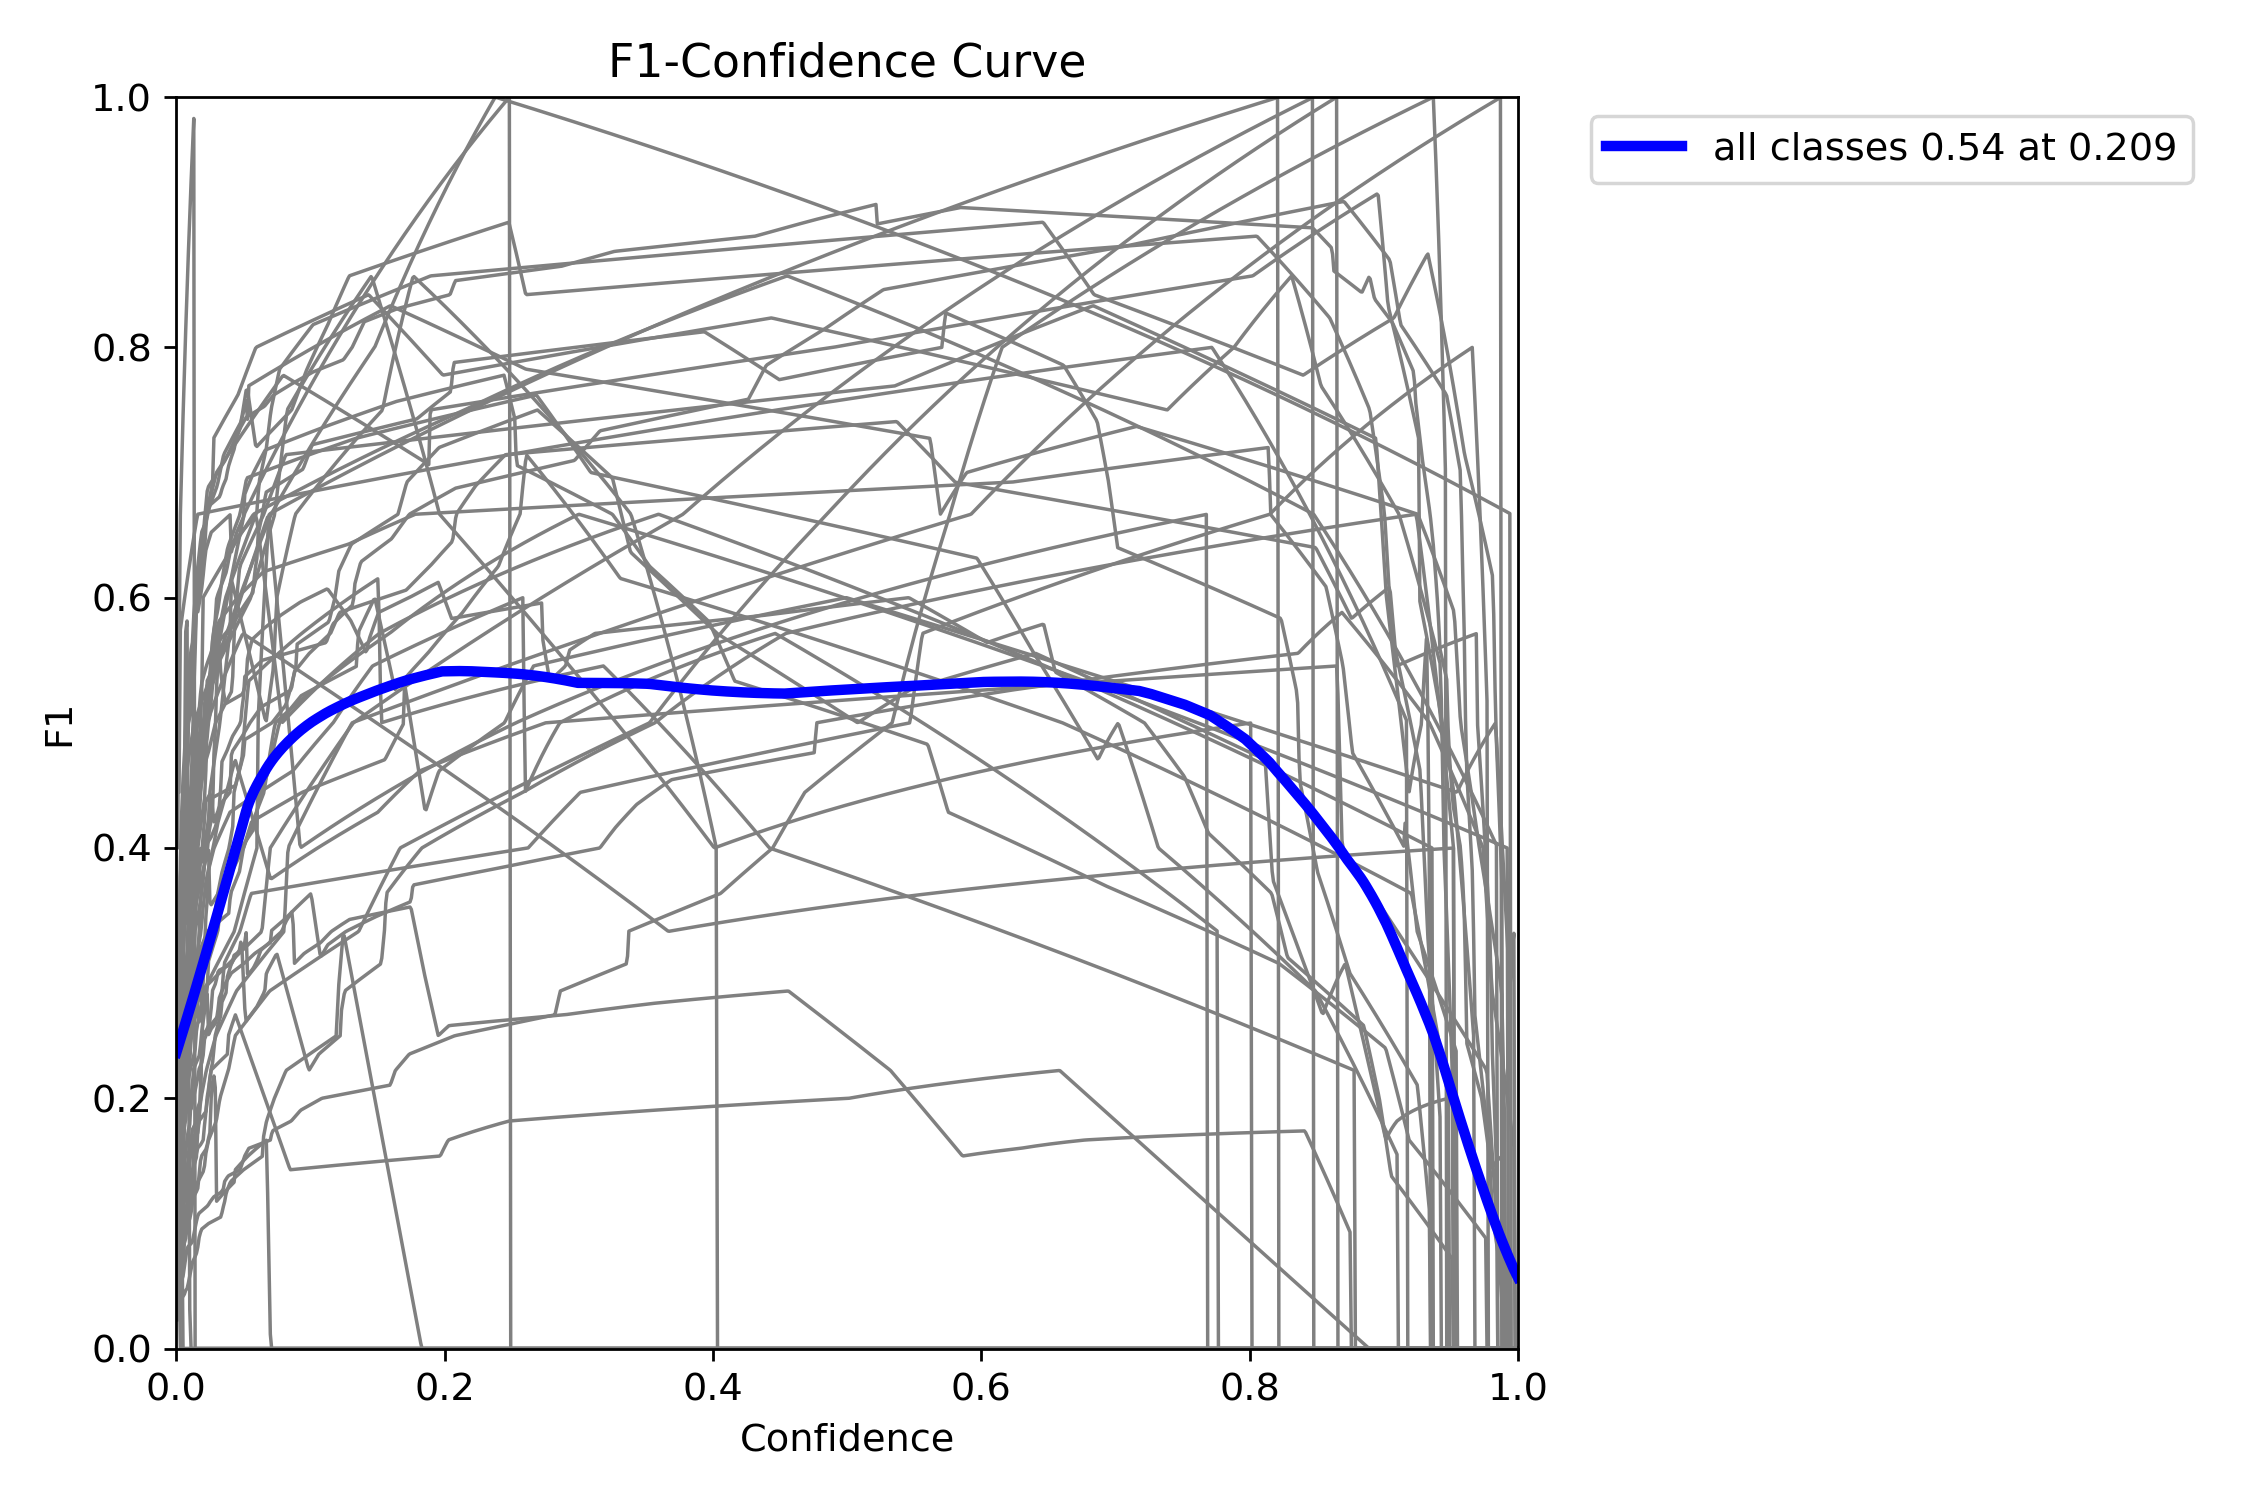

E:\NutritionProject\runs\nutrition_yolo11m_aug_v1_val\BoxP_curve.png


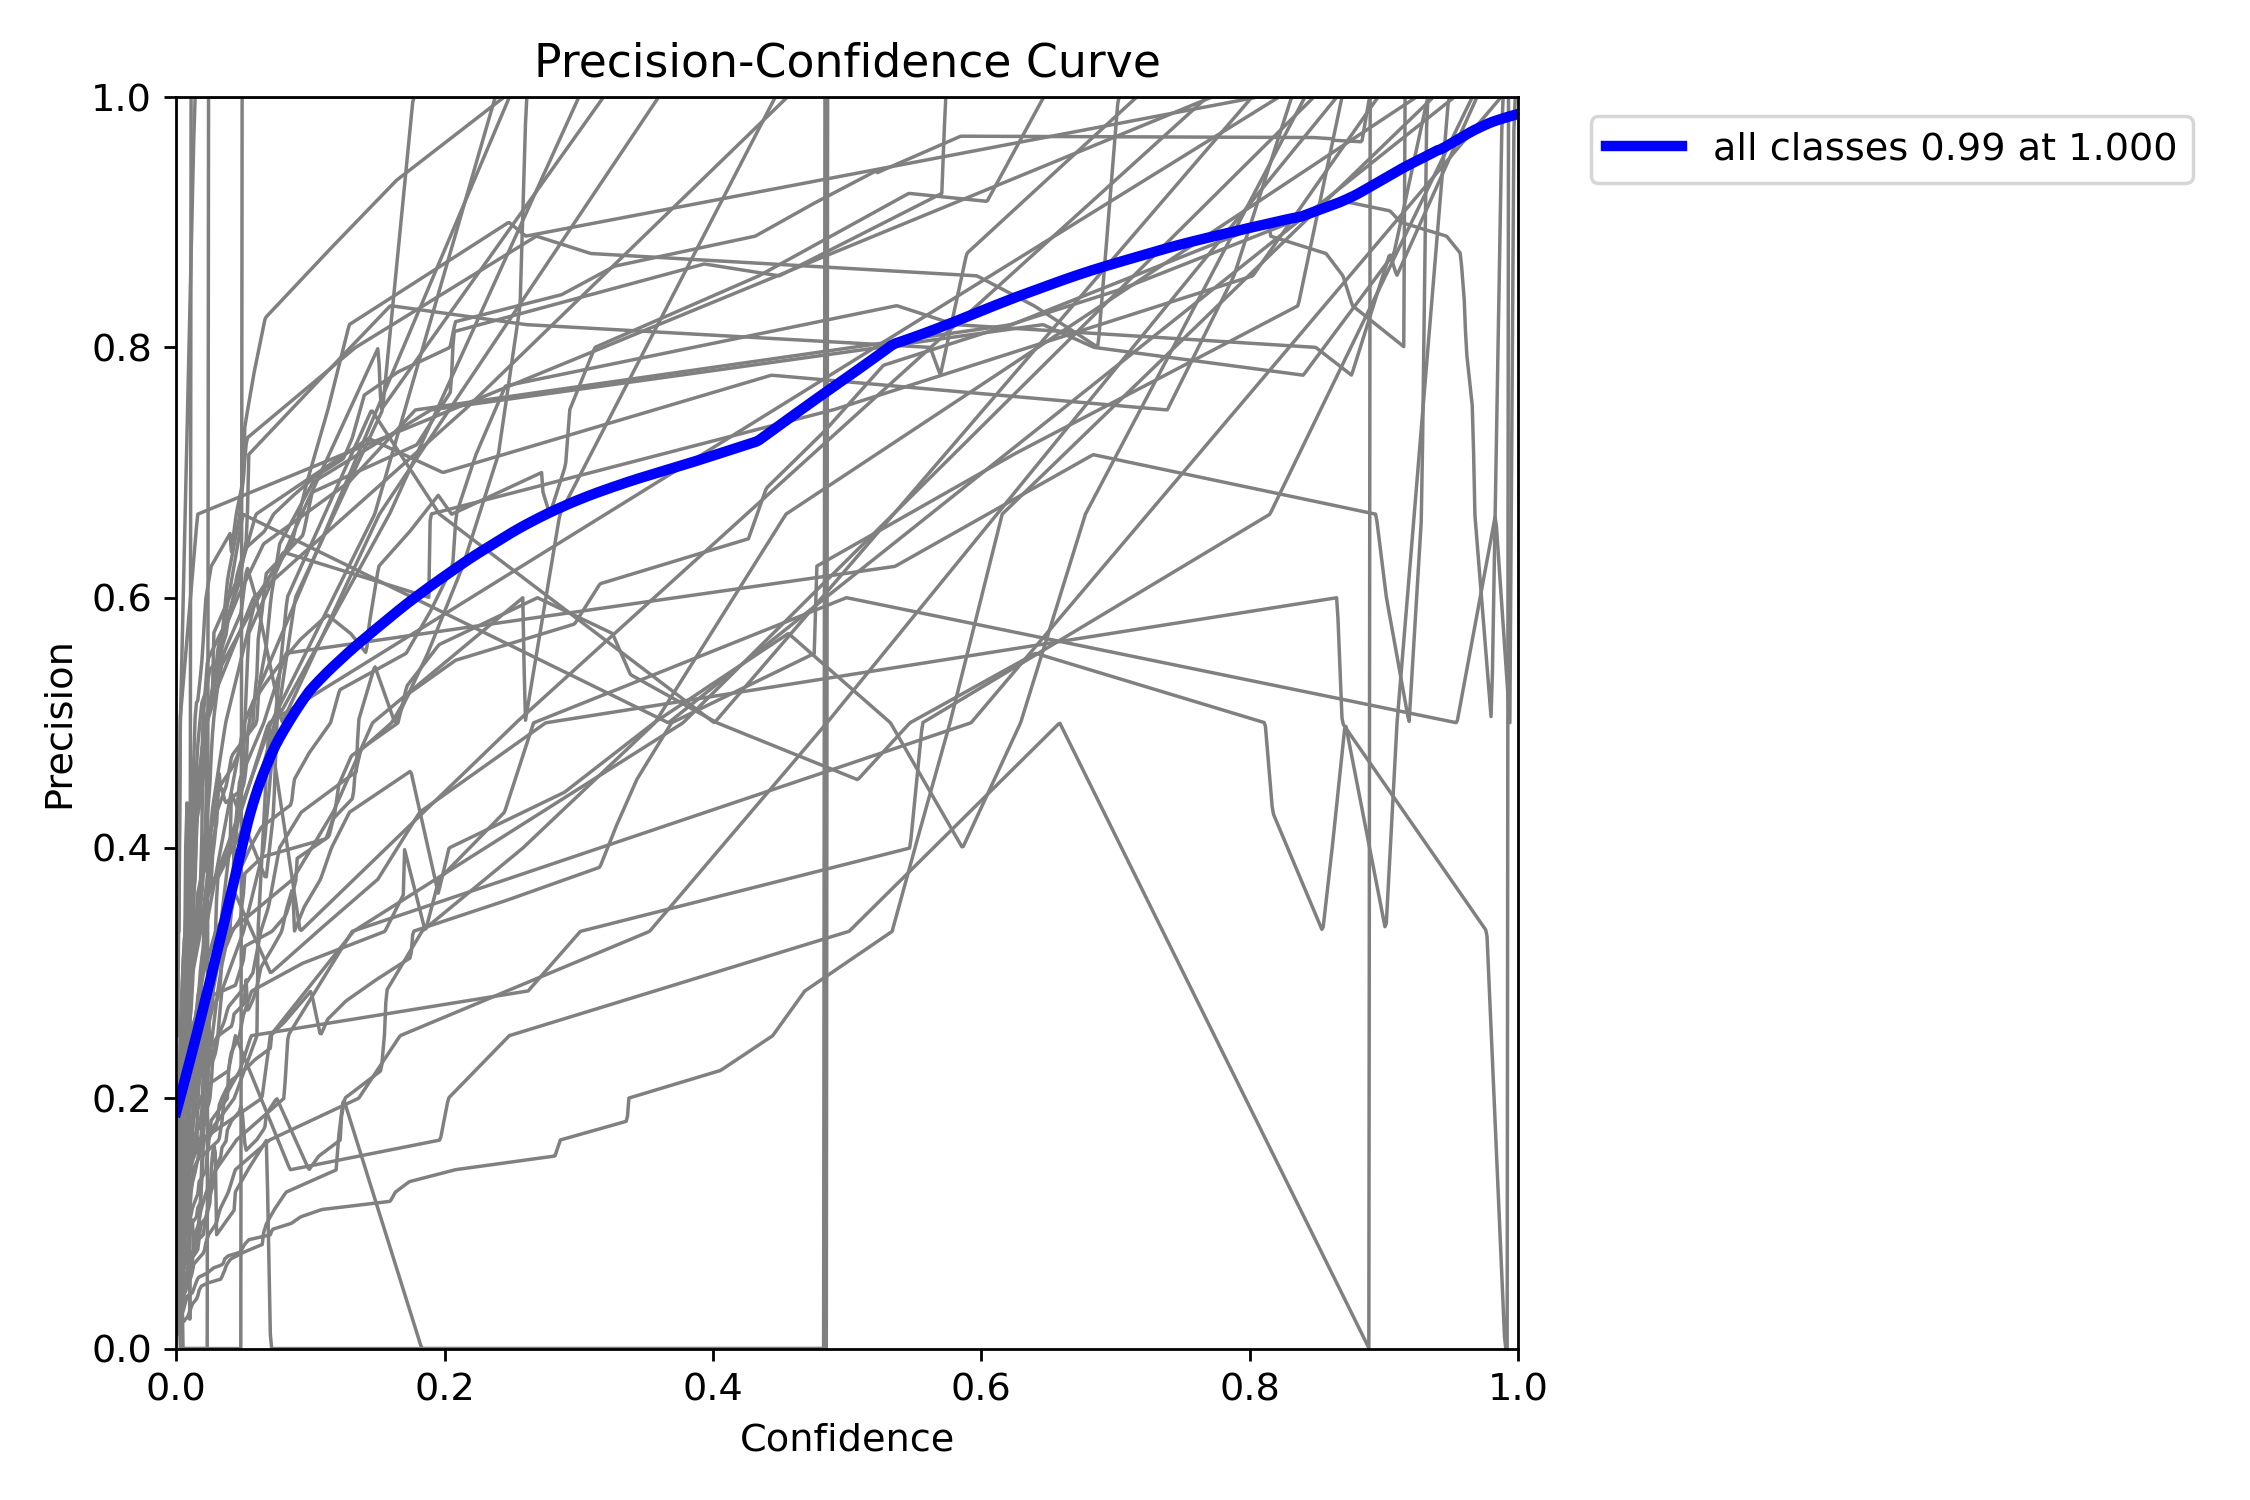

E:\NutritionProject\runs\nutrition_yolo11m_aug_v1_val\BoxR_curve.png


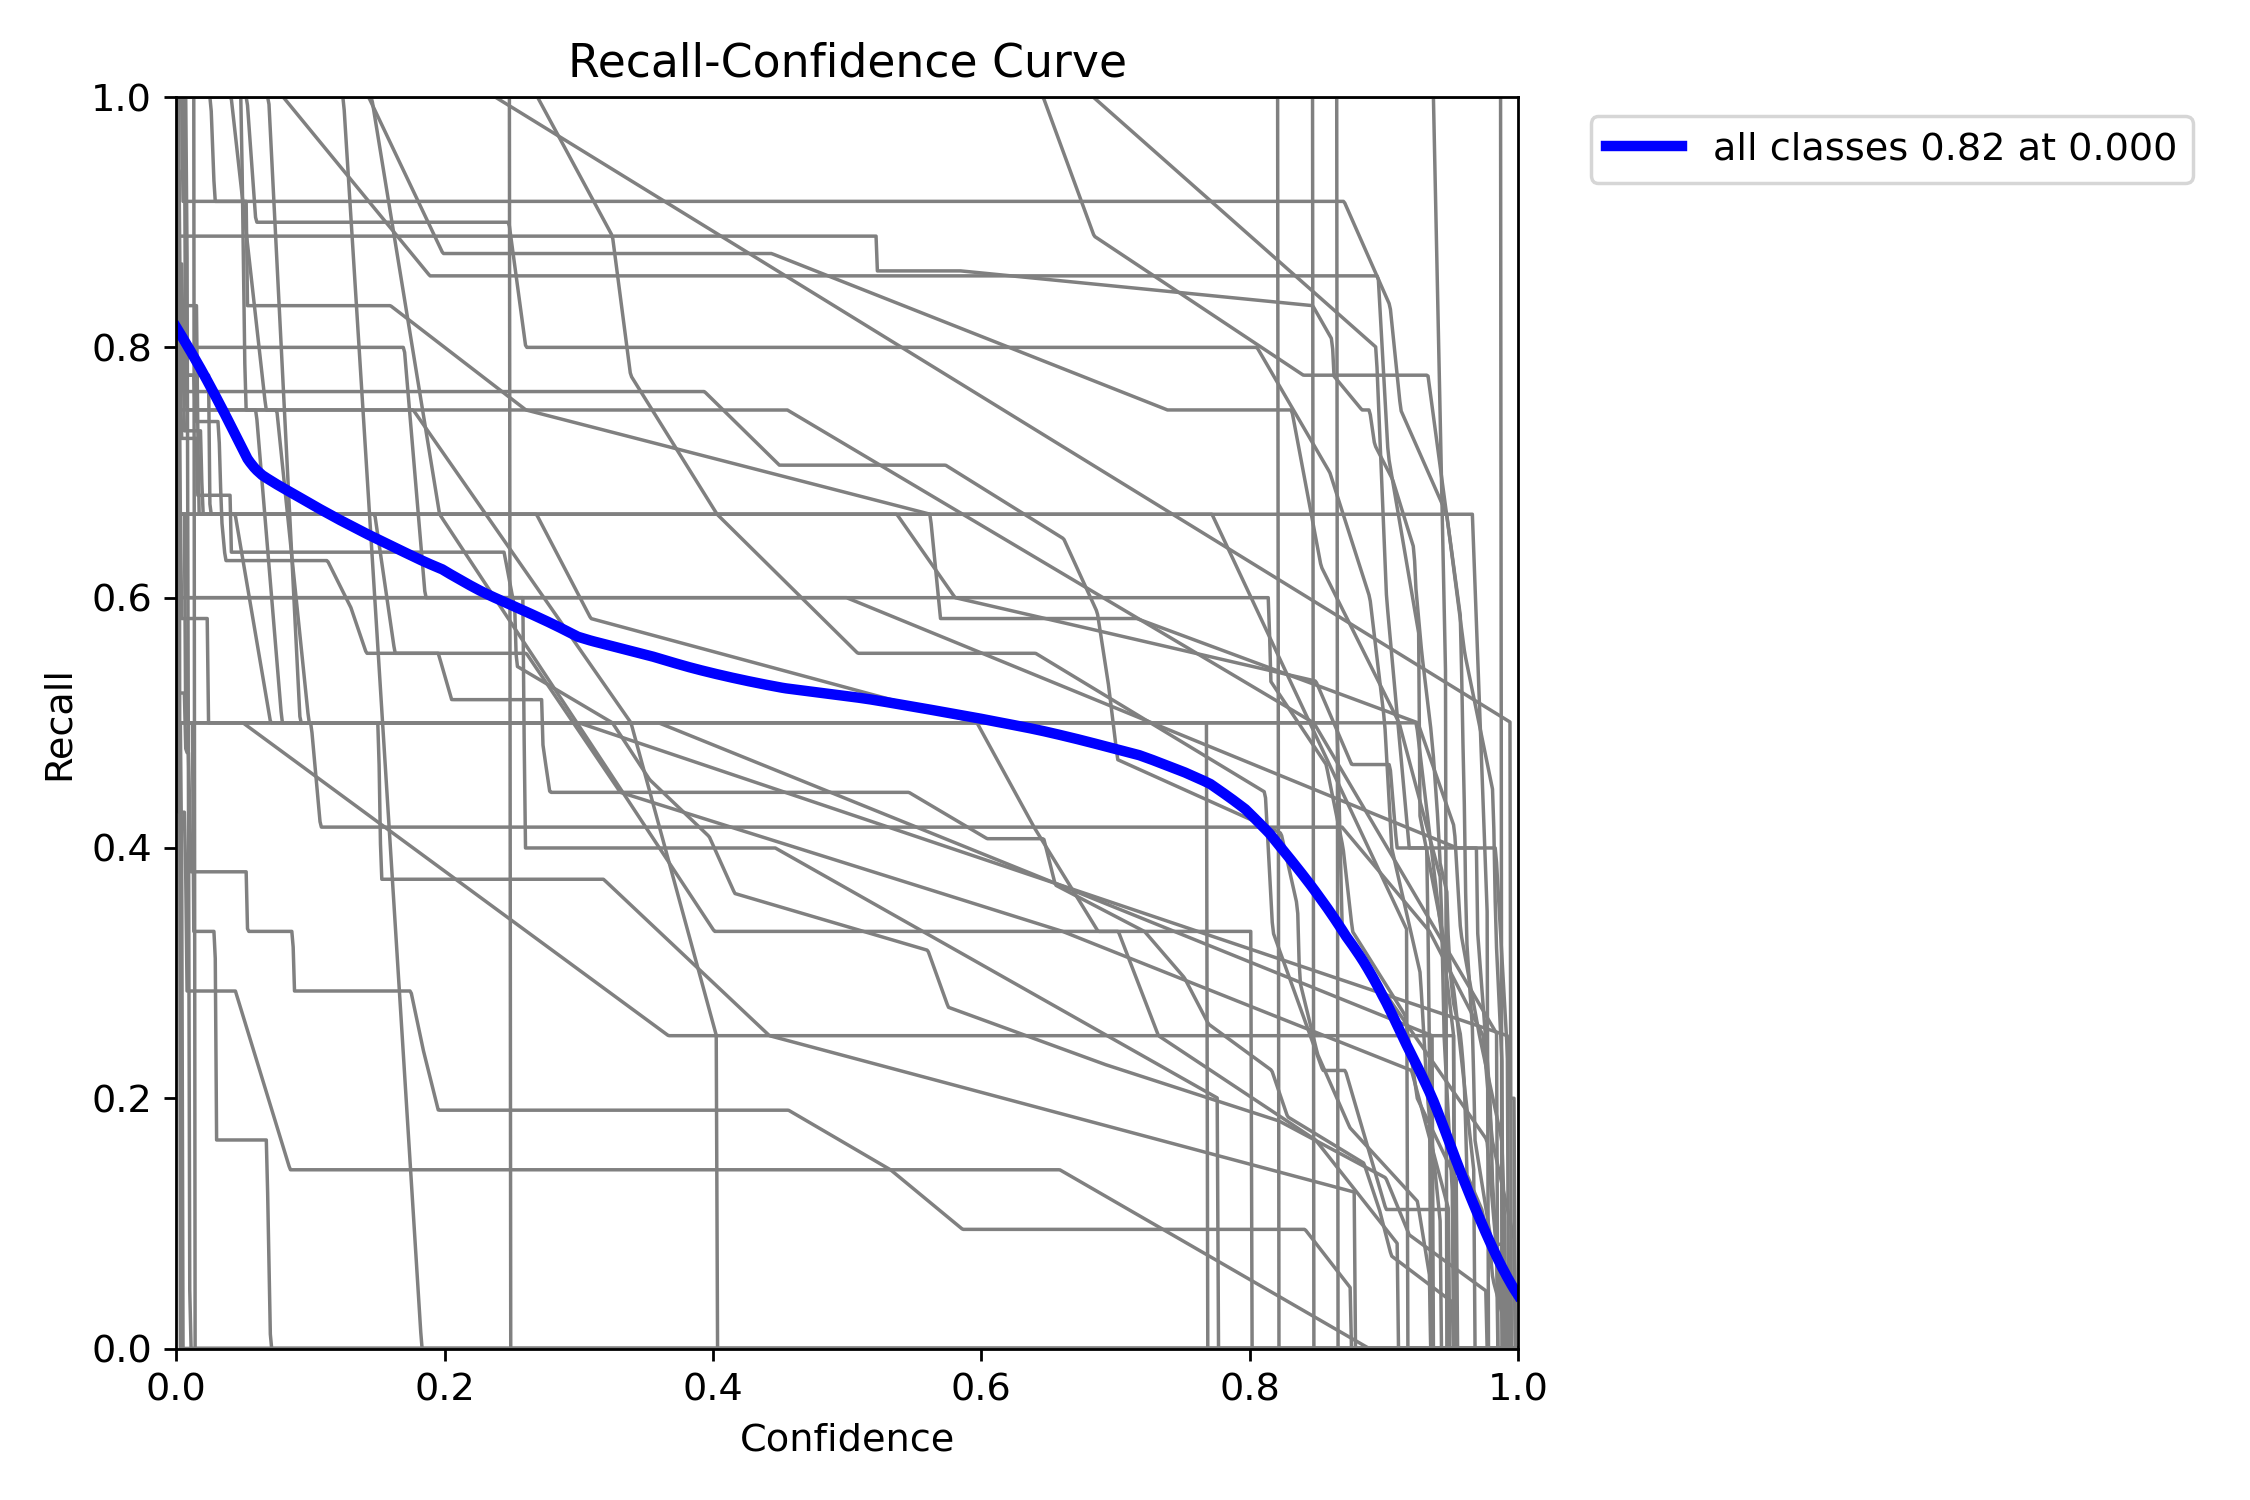

In [11]:
from pathlib import Path
from IPython.display import display, Image as IPyImage
import pandas as pd

best_model_path = RUNS_DIR / "nutrition_yolo11m_aug_v1" / "weights" / "best.pt"
val_model = YOLO(str(best_model_path))

metrics = val_model.val(
    data=str(DATA_YAML_PATH),
    imgsz=640,
    device=0,
    project=str(RUNS_DIR),
    name="nutrition_yolo11m_aug_v1_val",
    exist_ok=True,
    plots=True,
    split="test"
)

save_dir = Path(metrics.save_dir)

print("=== Overall metrics ===")
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

fitness = getattr(metrics, "fitness", None)
if fitness is not None:
    print(f"Fitness:   {fitness:.4f}")

print("\n=== Results dict ===")
for k, v in metrics.results_dict.items():
    try:
        print(f"{k}: {float(v):.4f}")
    except Exception:
        print(f"{k}: {v}")

print("\n=== Per-class metrics ===")
summary = metrics.summary()
df = pd.DataFrame(summary)

if "mAP50-95" in df.columns:
    df = df.sort_values("mAP50-95", ascending=False).reset_index(drop=True)

display(df)

csv_path = save_dir / "per_class_metrics.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"Per-class metrics saved to: {csv_path}")

print("\n=== Speed (ms/image) ===")
for k, v in metrics.speed.items():
    print(f"{k}: {v:.4f}")

print("\n=== Curves available ===")
print(metrics.curves)

plot_files = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
]

print("\n=== Saved plots ===")
for fname in plot_files:
    fpath = save_dir / fname
    if fpath.exists():
        print(fpath)
        display(IPyImage(filename=str(fpath)))
    else:
        print(f"Not found: {fpath}")

MODEL_PATH: E:\NutritionProject\runs\nutrition_yolo11m_aug_v1\weights\best.pt
DB_JSON_PATH: E:\NutritionProject\ml\data\nutrition_products_ru_kbju_100g.json
SAMPLES_DIR: E:\NutritionProject\ml\data\samples

Доступные изображения:
1. 155073800.jpg
2. 1674474106_balthazar-club-p-pankeiki-estetika-pinterest-90.jpg
3. 17500dcaefcfba76d0d0227807f069fe.png
4. 1da084fb1e511543a3da64479e21f6b4.jpg
5. 3134увцйва.jpg
6. 5f5af75255cf572b9c8281f2d3e4119a.jpg
7. 6932971200.jpg
8. 757-steak.jpg
9. 807726-Apples-Closeup-Red-Three-3-White-background.jpg
10. 9yZEF9RzNGP2_KR7gIdYVFFSFAUUBtpK.png
11. _normal.jpg
12. AA1PFfjA.jpg
13. bigstock-Pancakes-With-Banana-Walnuts-232673275.jpg
14. data[avatar]-1687773782802.jpg
15. diaporama-2-fumaison.jpg
16. l-intro-1730315671.jpg
17. large_151540548537vBzR.jpg
18. maxresdefault.jpg
19. maxresdefault1131.jpg
20. preview_preview_image-qX5BHpZkojYpqm6cnuYpKuauqDG5wm8-EA.jpg
21. przykazanie-4-diety-dr-Budwigwyjasnienie_s.jpg
22. rezat_riby.jpg
23. stejktuncakrupnoe

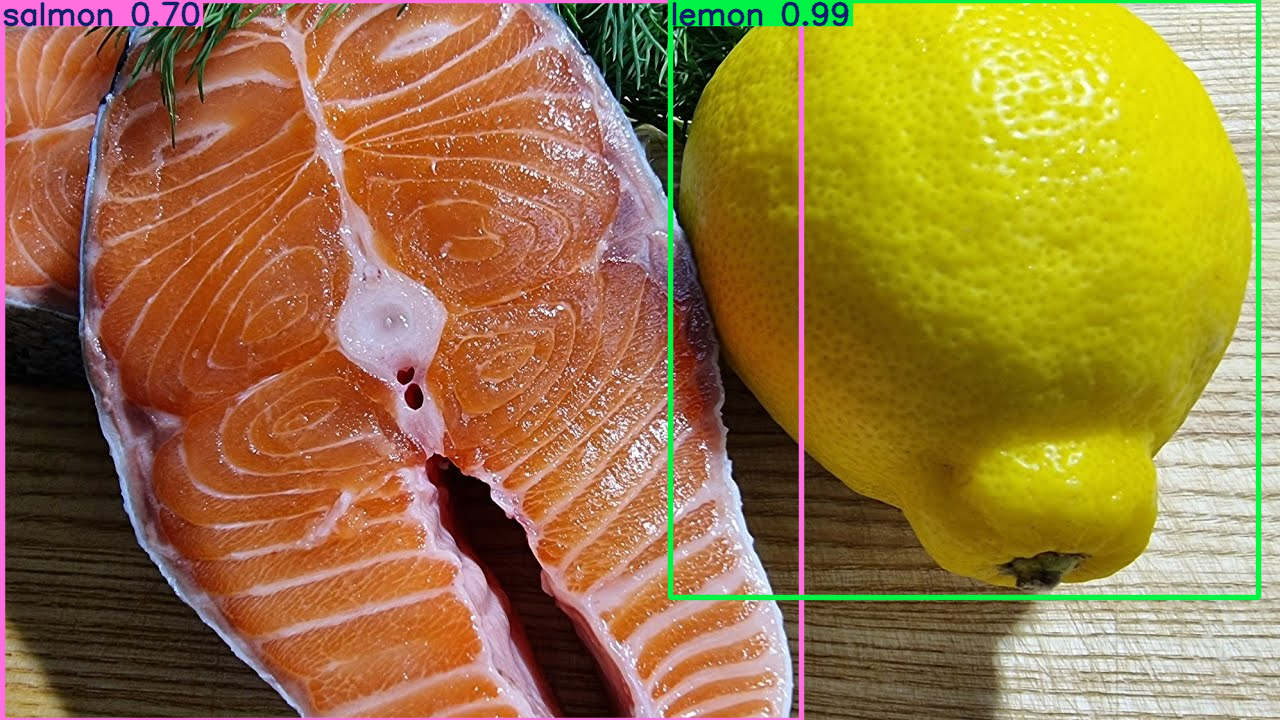


=== Подробная информация по уникальным распознанным продуктам ===

1. Продукт: лимон (lemon)
   Найдено объектов: 1
   Максимальная вероятность распознавания: 98.82%
   Пищевая ценность на 100 г:
   - Калории:  29 ккал
   - Белки:    1.1 г
   - Жиры:     0.3 г
   - Углеводы: 9.3 г

2. Продукт: лосось (salmon)
   Найдено объектов: 1
   Максимальная вероятность распознавания: 70.12%
   Пищевая ценность на 100 г:
   - Калории:  208 ккал
   - Белки:    20.0 г
   - Жиры:     13.0 г
   - Углеводы: 0.0 г

=== Краткая сводка ===

- лимон: 1 шт. обнаружений
- лосось: 1 шт. обнаружений

Примечание: значения КБЖУ являются справочными и указаны на 100 г продукта.


In [2]:
from pathlib import Path
from ultralytics import YOLO
from PIL import Image
from IPython.display import display
import json
from collections import defaultdict

# ===== 1. Пути проекта =====
PROJECT_ROOT = Path.cwd().resolve().parents[1]

ML_DIR = PROJECT_ROOT / "ml"
DATA_DIR = ML_DIR / "data"
RUNS_DIR = PROJECT_ROOT / "runs"
SAMPLES_DIR = DATA_DIR / "samples"

MODEL_PATH = RUNS_DIR / "nutrition_yolo11m_aug_v1" / "weights" / "best.pt"
DB_JSON_PATH = DATA_DIR / "nutrition_products_ru_kbju_100g.json"

print("MODEL_PATH:", MODEL_PATH)
print("DB_JSON_PATH:", DB_JSON_PATH)
print("SAMPLES_DIR:", SAMPLES_DIR)

# ===== 2. Проверка файлов =====
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Модель не найдена: {MODEL_PATH}")

if not DB_JSON_PATH.exists():
    raise FileNotFoundError(f"JSON база не найдена: {DB_JSON_PATH}")

if not SAMPLES_DIR.exists():
    raise FileNotFoundError(f"Папка samples не найдена: {SAMPLES_DIR}")

# ===== 3. Загрузка модели =====
model = YOLO(str(MODEL_PATH))

# ===== 4. Загрузка JSON базы =====
with open(DB_JSON_PATH, "r", encoding="utf-8") as f:
    nutrition_data = json.load(f)

product_index = {item["class_name"]: item for item in nutrition_data["products"]}

# ===== 5. Выбор изображения из папки ml/data/samples =====
IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".webp"]
sample_images = []

for ext in IMAGE_EXTS:
    sample_images.extend(SAMPLES_DIR.glob(f"*{ext}"))

sample_images = sorted(sample_images)

if not sample_images:
    raise FileNotFoundError(f"В папке {SAMPLES_DIR} нет изображений")

print("\nДоступные изображения:")
for i, img in enumerate(sample_images, start=1):
    print(f"{i}. {img.name}")

choice = int(input("\nВведите номер изображения: "))

if choice < 1 or choice > len(sample_images):
    raise ValueError("Некорректный номер изображения")

IMAGE_PATH = sample_images[choice - 1]
print(f"\nВыбрано изображение: {IMAGE_PATH}")

# ===== 6. Запуск распознавания =====
results = model.predict(
    source=str(IMAGE_PATH),
    conf=0.25,
    iou=0.45,
    imgsz=640,
    save=False,
    verbose=False
)

result = results[0]

# ===== 7. Показ изображения с bounding boxes =====
annotated = result.plot()
annotated_img = Image.fromarray(annotated[..., ::-1])

print("\nИзображение с результатами распознавания:")
display(annotated_img)

# ===== 8. Группировка распознанных продуктов =====
grouped_detections = defaultdict(lambda: {
    "count": 0,
    "max_confidence": 0.0,
    "class_name": None,
    "name_ru": None,
    "kcal_per_100g": None,
    "protein_per_100g": None,
    "fat_per_100g": None,
    "carbs_per_100g": None,
})

for box in result.boxes:
    cls_id = int(box.cls[0].item())
    conf = float(box.conf[0].item())
    class_name = result.names[cls_id]

    product_info = product_index.get(class_name)

    grouped_detections[class_name]["count"] += 1
    grouped_detections[class_name]["max_confidence"] = max(
        grouped_detections[class_name]["max_confidence"], conf
    )
    grouped_detections[class_name]["class_name"] = class_name
    grouped_detections[class_name]["name_ru"] = product_info["name_ru"] if product_info else class_name
    grouped_detections[class_name]["kcal_per_100g"] = product_info["kcal_per_100g"] if product_info else None
    grouped_detections[class_name]["protein_per_100g"] = product_info["protein_per_100g"] if product_info else None
    grouped_detections[class_name]["fat_per_100g"] = product_info["fat_per_100g"] if product_info else None
    grouped_detections[class_name]["carbs_per_100g"] = product_info["carbs_per_100g"] if product_info else None

unique_detections = sorted(
    grouped_detections.values(),
    key=lambda x: x["max_confidence"],
    reverse=True
)

# ===== 9. Подробный вывод =====
if not unique_detections:
    print("\nНа изображении не найдено распознаваемых продуктов.")
else:
    print("\n=== Подробная информация по уникальным распознанным продуктам ===\n")

    for i, item in enumerate(unique_detections, start=1):
        print(f"{i}. Продукт: {item['name_ru']} ({item['class_name']})")
        print(f"   Найдено объектов: {item['count']}")
        print(f"   Максимальная вероятность распознавания: {item['max_confidence']:.2%}")

        if item["kcal_per_100g"] is not None:
            print("   Пищевая ценность на 100 г:")
            print(f"   - Калории:  {item['kcal_per_100g']} ккал")
            print(f"   - Белки:    {item['protein_per_100g']} г")
            print(f"   - Жиры:     {item['fat_per_100g']} г")
            print(f"   - Углеводы: {item['carbs_per_100g']} г")
        else:
            print("   Пищевая ценность для этого класса не найдена в базе.")

        print()

# ===== 10. Краткая сводка =====
if unique_detections:
    print("=== Краткая сводка ===\n")
    for item in unique_detections:
        print(f"- {item['name_ru']}: {item['count']} шт. обнаружений")

    print("\nПримечание: значения КБЖУ являются справочными и указаны на 100 г продукта.")

In [6]:
from ultralytics import YOLO
from pathlib import Path
import shutil

PROJECT_ROOT = Path.cwd().parents[1]

pt_path = PROJECT_ROOT / "runs" / "nutrition_yolo11m_aug_v1" / "weights" / "best.pt"

model = YOLO(str(pt_path))

exported_path = model.export(
    format="onnx",
    imgsz=640,
    opset=12,
    simplify=True,
    dynamic=False,
)

print(exported_path)

Ultralytics 8.4.41  Python-3.13.0 torch-2.7.1+cu118 CPU (Intel Core i7-7700 3.60GHz)
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11m summary (fused): 126 layers, 20,070,895 parameters, 0 gradients, 67.9 GFLOPs

PyTorch: starting from 'e:\NutritionProject\runs\nutrition_yolo11m_aug_v1\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 57, 8400) (38.7 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   --- ------------------------------------ 1.3/16.4 MB 6.1 MB/s eta 0:00:03
   ------ --------------------------------- 2.6/16.4 MB 6.1 MB/s eta 0:00:03
   ---------- ----------------------------- 4.2/16.4 MB 6.3 MB/s eta 0:00:02
   --

In [ ]:
models_dir = PROJECT_ROOT / "ml_api" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

target_path = models_dir / "best_nutrivision.onnx"

shutil.copy(exported_path, target_path)

print("ONNX сохранён сюда:", target_path)

ONNX сохранён сюда: e:\NutritionProject\ml\models\best.onnx
